# Loan Amount Prediction using Linear Regression

## Project Overview
This project predicts the loan amount a person qualifies for based on their financial profile. This is a classic regression problem widely used in BFSI and Fintech companies for credit decisioning and loan eligibility assessment.

## Domain
Banking, Financial Services & Insurance (BFSI) / Fintech

## Technique
Multiple Linear Regression with Regularisation (Ridge & Lasso)

## Dataset
Credit Risk Dataset — Kaggle

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print("All libraries imported successfully")

All libraries imported successfully


In [7]:
df = pd.read_csv('../data/credit_risk_dataset.csv')

print("DATASET LOADED SUCCESSFULLY")

print(f"\nShape: {df.shape}")

print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nColumn names and data types:")
print(df.dtypes)

print("\nBasic statistics:")
print(df.describe())

print("\nMissing values per column:")
print(df.isnull().sum())

DATASET LOADED SUCCESSFULLY

Shape: (32581, 12)

First 5 rows:
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0               

## Data Cleaning

### Observations from first look:
- `person_emp_length` has 895 missing values → fill with median
- `loan_int_rate` has 3116 missing values → fill with median
- `person_age` has a max of 144 → impossible, filter out age > 100
- `person_emp_length` has a max of 123 → impossible, filter out emp_length > 60
- Categorical columns need to be encoded before modelling

In [8]:
# ── Drop impossible ages and employment lengths ─────────────
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]

print(f"Shape after removing outliers: {df.shape}")

# ── Fill missing values with median ─────────────────────────
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Shape after removing outliers: (31679, 12)

Missing values after cleaning:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


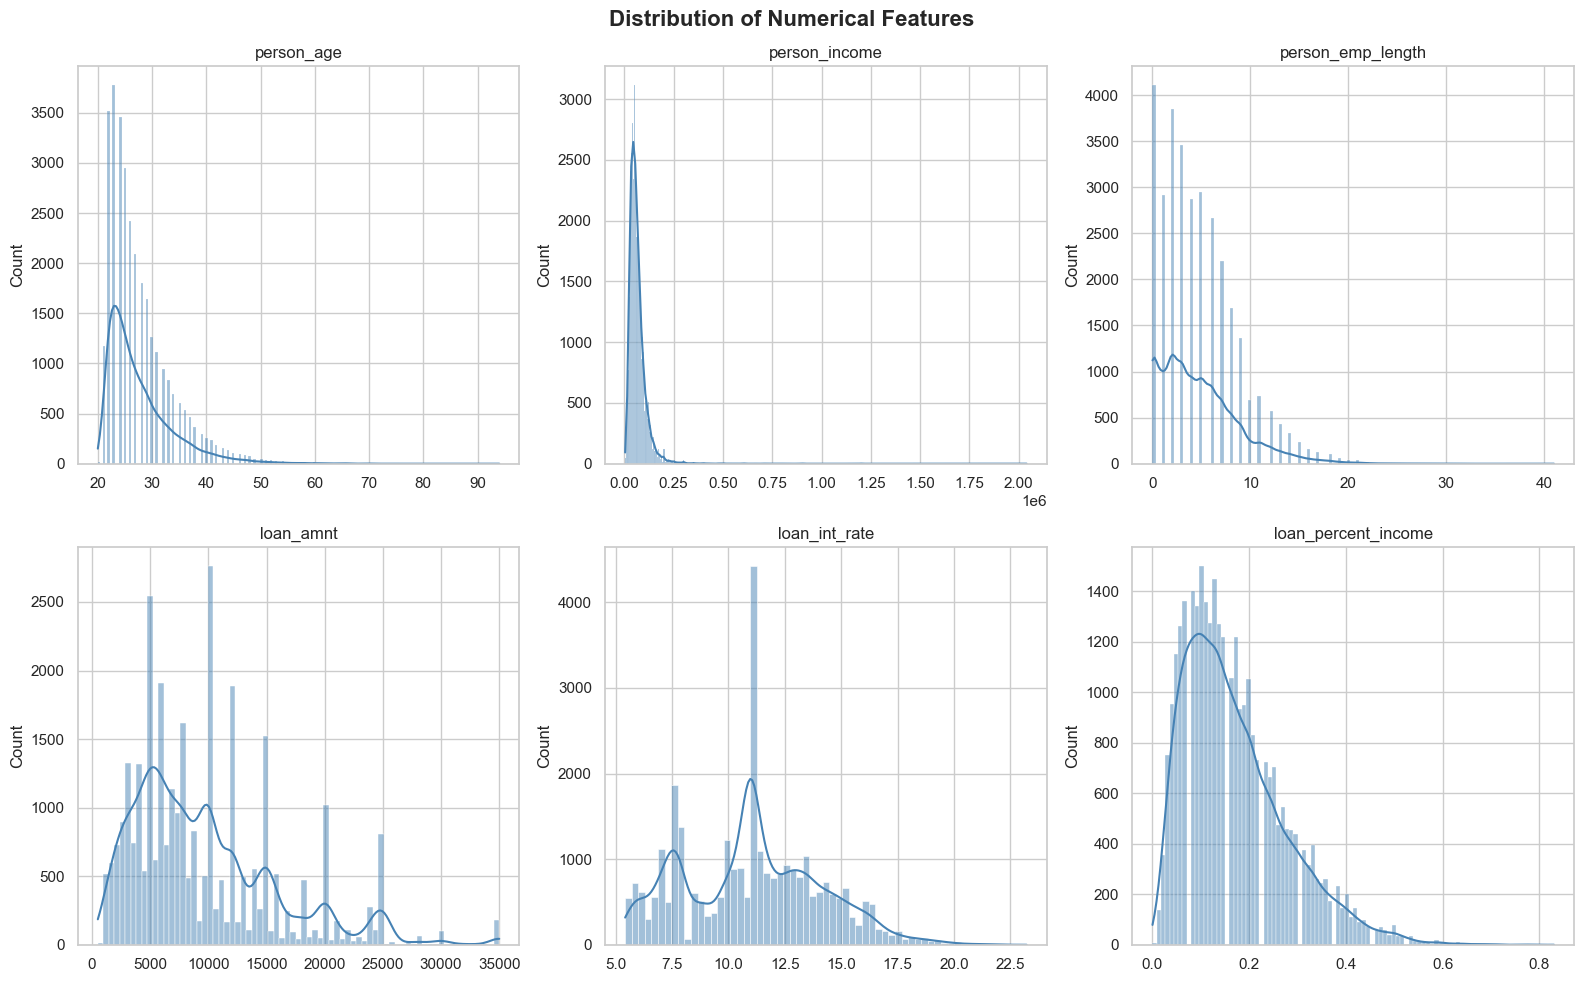

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income']

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### Loan Amount vs Categorical Features

Analysing how loan amount varies across different categories of home ownership and loan intent. This helps us understand which categorical features influence the target variable.

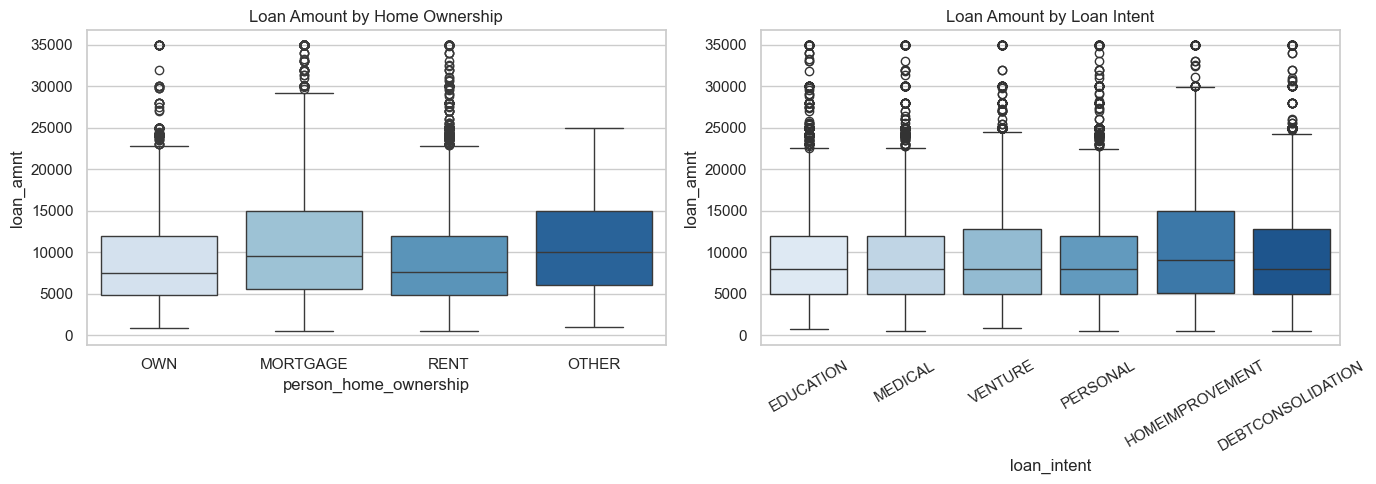

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df, x='person_home_ownership', y='loan_amnt', hue='person_home_ownership', 
    ax=axes[0], palette='Blues', legend=False)

axes[0].set_title('Loan Amount by Home Ownership')

sns.boxplot(
    data=df, x='loan_intent', y='loan_amnt', hue='loan_intent',
    ax=axes[1], palette='Blues', legend=False)

axes[1].set_title('Loan Amount by Loan Intent')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Correlation Heatmap

Checking linear relationships between all numerical features.
Key things to look for:
- Which features correlate strongly with `loan_amnt` (our target)
- Which features correlate strongly with each other (multicollinearity)

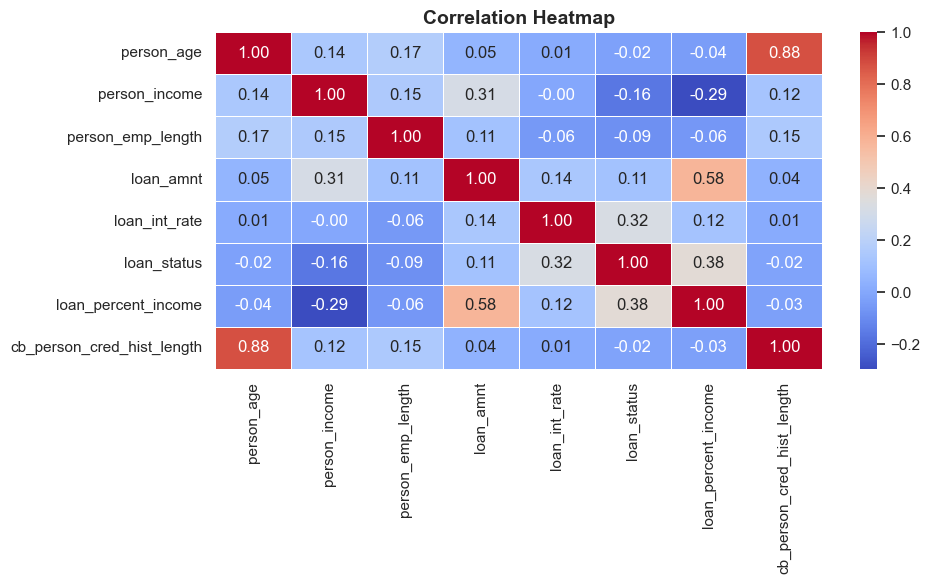

In [13]:
# Correlation heatmap — numerical columns only
plt.figure(figsize=(10, 6))
num_df = df.select_dtypes(include=np.number)
sns.heatmap(num_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Observations from EDA

**Target variable correlations with loan_amnt:**
- `loan_percent_income` → 0.58 (strongest predictor)
- `person_income` → 0.31 (moderate)
- `loan_int_rate` → 0.14 (weak)
- `person_emp_length` → 0.11 (weak)
- `person_age` → 0.05 (negligible)

**Multicollinearity detected:**
- `person_age` and `cb_person_cred_hist_length` → 0.88 correlation
- These two carry the same information (older people have longer credit history)
- Decision: drop `cb_person_cred_hist_length`, keep `person_age`

**Skewed features that need log transformation:**
- `person_income` — heavily right skewed
- `person_emp_length` — right skewed

**Categorical features to encode:**
- `person_home_ownership`, `loan_intent`, `loan_grade`, `cb_person_default_on_file`

In [14]:
# ── Feature Engineering ───────────────────────────────

# ── Drop multicollinear column ───────────────────────────────
df = df.drop(columns=['cb_person_cred_hist_length'])

# ── Log transform skewed features ───────────────────────────
df['log_income'] = np.log1p(df['person_income'])
df['log_emp_length'] = np.log1p(df['person_emp_length'])

# ── Interaction feature ──────────────────────────────────────
# Income per year of employment — measures income growth rate
df['income_per_emp_year'] = df['person_income'] / (df['person_emp_length'] + 1)

# ── One-hot encode categorical columns ──────────────────────
df = pd.get_dummies(df, columns=['person_home_ownership',
                                  'loan_intent',
                                  'loan_grade',
                                  'cb_person_default_on_file'],
                    drop_first=True)

print(f"Shape after feature engineering: {df.shape}")
print(f"\nAll columns now:")
print(df.columns.tolist())

Shape after feature engineering: (31679, 25)

All columns now:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'log_income', 'log_emp_length', 'income_per_emp_year', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y']


## Prepare Features and Target

Dropping original skewed columns since we now have log-transformed versions. Separating features (X) and target (y), then splitting into train and test sets.

In [15]:
# ── Drop original skewed columns ────────────────────────────
df = df.drop(columns=['person_income', 'person_emp_length'])

# ── Separate features and target ────────────────────────────
X = df.drop(columns=['loan_amnt'])
y = df['loan_amnt']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used:")
print(X.columns.tolist())

# ── Train test split ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Features shape: (31679, 22)
Target shape: (31679,)

Features used:
['person_age', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'log_income', 'log_emp_length', 'income_per_emp_year', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y']

Training set: (25343, 22)
Test set:     (6336, 22)


## Feature Scaling

Applying StandardScaler to normalise all features to the same scale. Fitting only on training data, then transforming both train and test. This prevents data leakage from test set into the model.

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")
print(f"Training mean (first 3 features): {X_train_scaled[:, :3].mean(axis=0).round(4)}")
print(f"Training std  (first 3 features): {X_train_scaled[:, :3].std(axis=0).round(4)}")

Scaling done.
Training mean (first 3 features): [-0. -0.  0.]
Training std  (first 3 features): [1. 1. 1.]


## Model Training and Evaluation

Training three models and comparing:
1. **Linear Regression** — baseline, no regularisation
2. **Ridge Regression** — L2 regularisation, handles overfitting
3. **Lasso Regression** — L1 regularisation, also does feature selection

In [24]:
# ── Helper function to evaluate any model ───────────────────
def evaluate_model(name, y_test, y_pred, y_train_actual, y_train_pred):
    test_r2   = r2_score(y_test, y_pred)
    train_r2  = r2_score(y_train_actual, y_train_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    n = len(y_test)
    k = X_test_scaled.shape[1]
    adj_r2 = 1 - (1 - test_r2) * (n - 1) / (n - k - 1)

    print(f"  {name}")
    print ()
    print(f"  Train R²:      {train_r2:.4f}")
    print(f"  Test R²:       {test_r2:.4f}")
    print(f"  Adjusted R²:   {adj_r2:.4f}")
    print(f"  RMSE:          ₹{test_rmse:,.0f}")
    gap = train_r2 - test_r2
    status = "✅ Good fit" if gap < 0.05 else "⚠️ Slight overfit" if gap < 0.1 else "❌ Overfit"
    print(f"  Train-Test Gap:{gap:.4f}  →  {status}")
    print()

    return test_r2, adj_r2, test_rmse

results = {}

# ── 1. Linear Regression ─────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_train_pred = lr.predict(X_train_scaled)
lr_test_pred  = lr.predict(X_test_scaled)
r2, adj_r2, rmse = evaluate_model("Linear Regression",
                                   y_test, lr_test_pred,
                                   y_train, lr_train_pred)
results['Linear Regression'] = {'R2': r2, 'Adj_R2': adj_r2, 'RMSE': rmse}

# ── 2. Ridge Regression ──────────────────────────────────────
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred  = ridge.predict(X_test_scaled)
r2, adj_r2, rmse = evaluate_model("Ridge Regression (alpha=1.0)",
                                   y_test, ridge_test_pred,
                                   y_train, ridge_train_pred)
results['Ridge'] = {'R2': r2, 'Adj_R2': adj_r2, 'RMSE': rmse}

# ── 3. Lasso Regression ──────────────────────────────────────
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred  = lasso.predict(X_test_scaled)
r2, adj_r2, rmse = evaluate_model("Lasso Regression (alpha=0.1)",
                                   y_test, lasso_test_pred,
                                   y_train, lasso_train_pred)
results['Lasso'] = {'R2': r2, 'Adj_R2': adj_r2, 'RMSE': rmse}

  Linear Regression

  Train R²:      0.8189
  Test R²:       0.8183
  Adjusted R²:   0.8176
  RMSE:          ₹2,704
  Train-Test Gap:0.0006  →  ✅ Good fit

  Ridge Regression (alpha=1.0)

  Train R²:      0.8189
  Test R²:       0.8183
  Adjusted R²:   0.8176
  RMSE:          ₹2,704
  Train-Test Gap:0.0006  →  ✅ Good fit

  Lasso Regression (alpha=0.1)

  Train R²:      0.8189
  Test R²:       0.8183
  Adjusted R²:   0.8176
  RMSE:          ₹2,704
  Train-Test Gap:0.0006  →  ✅ Good fit



## Residual Analysis

Plotting residuals to visually verify model assumptions. A good model should show residuals randomly scattered around zero with no pattern.

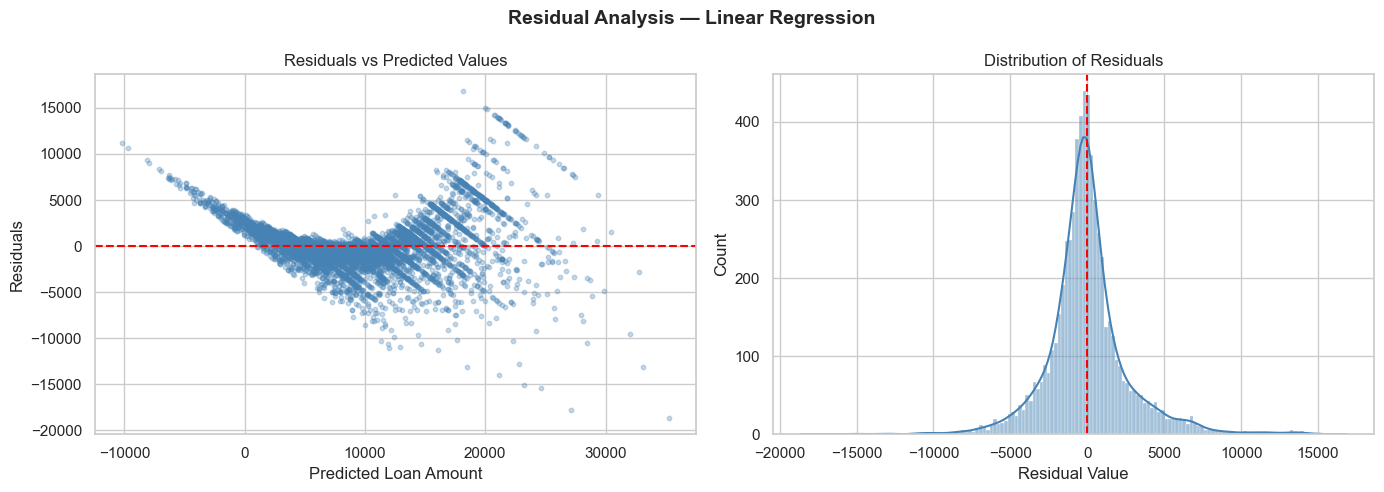

Mean of residuals:   -2.6228  (should be close to 0)
Std of residuals:    2703.79


In [18]:
residuals = y_test - lr_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residual Analysis — Linear Regression', fontsize=14, fontweight='bold')

# ── Plot 1: Residuals vs Predicted ──────────────────────────
axes[0].scatter(lr_test_pred, residuals, alpha=0.3, color='steelblue', s=10)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Loan Amount')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted Values')

# ── Plot 2: Distribution of residuals ───────────────────────
sns.histplot(residuals, kde=True, ax=axes[1], color='steelblue')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual Value')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

print(f"Mean of residuals:   {residuals.mean():.4f}  (should be close to 0)")
print(f"Std of residuals:    {residuals.std():.2f}")

## Feature Importance — Coefficient Analysis

Analysing which features have the most influence on loan amount prediction. Larger absolute coefficient = stronger influence on the predicted loan amount.

Feature Coefficients (sorted by importance):
                    Feature  Coefficient
        loan_percent_income  5450.050336
                 log_income  4814.896678
        income_per_emp_year  -353.268044
                loan_status  -270.454513
             log_emp_length  -236.821629
               loan_grade_D   221.592931
              loan_int_rate   221.172873
               loan_grade_E   175.410213
               loan_grade_F   159.398383
               loan_grade_B   156.010908
               loan_grade_G   100.234727
 person_home_ownership_RENT   -75.244045
        loan_intent_MEDICAL    51.041394
  person_home_ownership_OWN   -47.714067
person_home_ownership_OTHER   -36.996136
        loan_intent_VENTURE   -36.406914
cb_person_default_on_file_Y    29.288202
                 person_age   -28.549555
loan_intent_HOMEIMPROVEMENT    16.621009
       loan_intent_PERSONAL   -16.069732
      loan_intent_EDUCATION   -12.554581
               loan_grade_C     8.287869


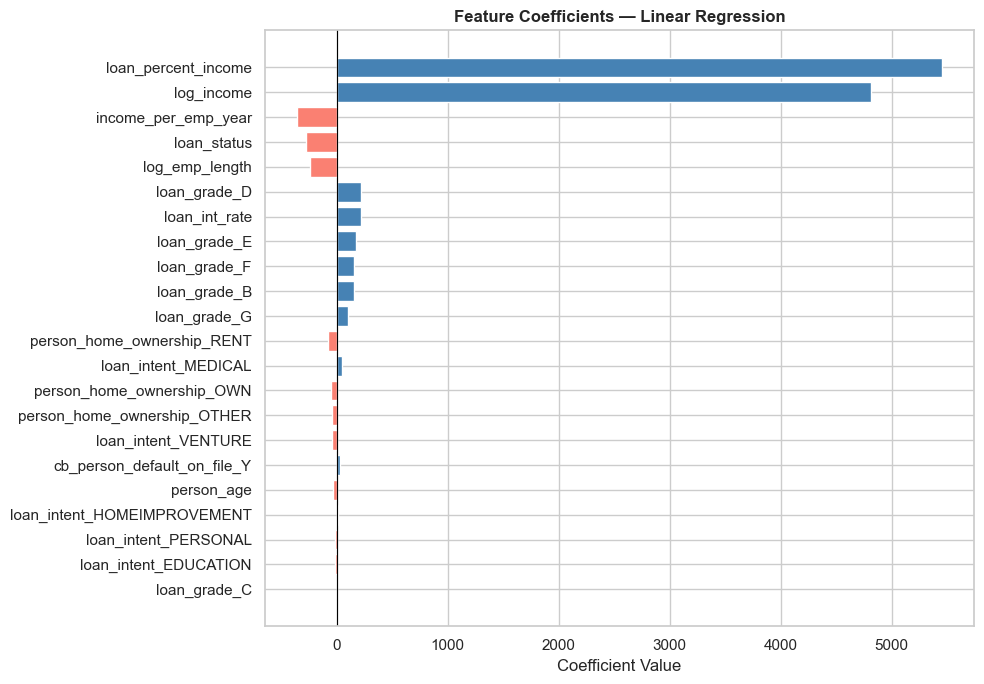

In [19]:
feature_names = X.columns.tolist()
coefficients  = lr.coef_

coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coefficients
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

print("Feature Coefficients (sorted by importance):")
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

# ── Plot ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients — Linear Regression', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
# Model Comparison Summary
summary_df = pd.DataFrame(results).T
summary_df.index.name = 'Model'
summary_df = summary_df.round(4)
print(summary_df)

                       R2  Adj_R2       RMSE
Model                                       
Linear Regression  0.8183  0.8176  2703.5820
Ridge              0.8183  0.8176  2703.5835
Lasso              0.8183  0.8176  2703.5527


In [ ]:
import joblib

# Save model and scaler
joblib.dump(lr, '../scripts/loan_regression_model.pkl')
joblib.dump(scaler, '../scripts/scaler.pkl')

print("Model saved to scripts/loan_regression_model.pkl")
print("Scaler saved to scripts/scaler.pkl")

## LOAN AMOUNT PREDICTION — PROJECT SUMMARY        

## DATASET
───────
  Rows after cleaning : 31,679
  Features used       : 22
  Target variable     : loan_amnt (₹500 – ₹35,000)

## MODEL PERFORMANCE
─────────────────
  Best Model   : Linear Regression (all three tied)
  Test R²      : 0.8183  → model explains 81.83% of variance
  Adjusted R²  : 0.8176
  RMSE         : ₹2,704  → average prediction error

## KEY FINDINGS
────────────
  1. loan_percent_income is the strongest predictor (coef: +5450) → Banks size loans primarily based on income-to-loan ratio

  2. log_income is the second strongest predictor (coef: +4814) → Higher earners consistently qualify for larger loans

  3. Loan grade affects amount — riskier borrowers (Grade D/E/F) take larger loans, which is why they carry higher interest rates

  4. Regularisation (Ridge/Lasso) had no effect — the baseline linear model was already well-fitted with no overfitting

## LIMITATIONS
───────────
  1. Heteroscedasticity detected in residuals — model errors growfor higher loan amounts. A tree-based model (Random Forest, XGBoost) would likely handle this better.

  2. Residuals are not perfectly normally distributed — peaked centre with a long left tail.

  3. Loan amounts cluster at round numbers (5000, 10000, 35000) which creates multimodal patterns linear regression cannot fully capture.

## NEXT STEPS
──────────
  → Try Random Forest or XGBoost for better handling of heteroscedasticity and non-linear patterns
  → Hyperparameter tune Ridge/Lasso alpha using cross-validation
  → Apply this same dataset for classification (loan_status) using Logistic Regression